# Fit `HGQ-Hybrid — Muon tracking, 2.03 mrad` into ~15% fewer LUTs

Uses **`da4ml.pack.fit_model`** to pack this model onto the Table III reference part `xczu7ev-ffvc1156-2-e` under a LUT budget of **0.85 × 19,627 = 16,683 LUT** (target −15%), offloading lookups→BRAM / adders→DSP (bit-exact). Every HGQ-* row in Table III uses **DSP = 0**, so the unused BRAM/DSP on the board is exactly the headroom we trade LUTs into.

`fit_model` calibrates a per-model LUT/FF/BRAM/DSP cost model from **3 synth-only
Vivado anchors**, picks the predicate that fits by pure arithmetic (min DSP, then
min BRAM), and — with `confirm=True` — routes the winner once to validate.

Method + model registry live in [`../_fit_common.py`](../_fit_common.py).


In [1]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()
KEY = NB_DIR.name                       # folder name == model key
if str(NB_DIR.parent) not in sys.path:
    sys.path.insert(0, str(NB_DIR.parent))

import _fit_common as fc
assert KEY in fc.MODELS, (
    f'cwd is {NB_DIR} (folder {KEY!r}); run this notebook from its own model folder. '
    f'Known models: {list(fc.MODELS)}')
cfg = fc.MODELS[KEY]
cap = cfg.part_cap

print(f'Model   : {cfg.title}')
print(f'Part    : {cfg.part_name}  ({cap["lut"]:,} LUT / {cap["ff"]:,} FF / {cap["bram"]} BRAM / {cap["dsp"]} DSP)')
print(f'Baseline: {cfg.baseline_lut:,} LUT (Table III), DSP 0')
if cfg.part_constrained:
    over = cfg.baseline_lut - cap['lut']
    print(f'Target  : physically fit the part (budget {cap["lut"]:,} LUT / {cap["bram"]} BRAM / {cap["dsp"]} DSP, '
          f'default margins) -- baseline overflows by {over:,} LUT ({over / cap["lut"] * 100:.0f}%)')
else:
    print(f'Target  : LUT budget {cfg.lut_budget:,} (0.85x baseline, -15%); FF/BRAM/DSP unconstrained')
print(f'Clock   : {cfg.clock_period} ns   latency cutoff {cfg.latency_cutoff} ns')


Model   : HGQ-Hybrid — Muon tracking, 2.03 mrad
Part    : xczu7ev-ffvc1156-2-e  (230,400 LUT / 460,800 FF / 312 BRAM / 1728 DSP)
Baseline: 19,627 LUT (Table III), DSP 0
Target  : LUT budget 16,683 (0.85x baseline, -15%); FF/BRAM/DSP unconstrained
Clock   : 6.25 ns   latency cutoff 8 ns


## 1) Load + trace → base `comb`

Uses the cached `trace_minmax`'d checkpoint if present, else traces over train+val once and caches it. `fit_model` needs only this `comb`.

In [2]:
comb = fc.load_traced_comb(cfg)


Using cached trace: traced_2.03mrad.keras
Traced: cost=23347  ops=7404  lookups(op8)=575  vmul(op7)=0


## 2) `fit_model` — calibrate (3 synth-only runs) → pick → confirm route

In [3]:
result = fc.run_fit(cfg, comb, confirm=True)
print()
print(result.summary())


[vivado] start A0_baseline
[vivado] start A1_bram_max
[vivado] start A2_dsp_cal
[vivado] done A1_bram_max  rc=0  t=282s
[vivado] done A0_baseline  rc=0  t=300s
[vivado] done A2_dsp_cal  rc=0  t=369s
[synth] A0_baseline    LUT*=18959 FF=4988 BRAM=0.0 DSP=0
[synth] A1_bram_max    LUT*=15518 FF=6537 BRAM=139.0 DSP=0
[synth] A2_dsp_cal     LUT*=15896 FF=3241 BRAM=0.0 DSP=469
ResourceModel(part='xczu7ev-ffvc1156-2-e', clk=6.25, cutoff=8
  LUT*  = 967 + 0.7706*cost - 1.2569*dsp_adder_cost  (route x0.977)
  FF*   = 4272 + 0.1381*reg_bits  (route x0.999)
  BRAM  = exact RAMB18/RAMB36 tiles from IR geometry
  DSP   = 0.5733 * n_promoted_adders)
[route] fit  LUT=16607 FF=7568 BRAM=65.0 DSP=0  WNS=+0.518 Fmax=174.5MHz  t=403s
FIT: bram(7, 5)_dsp-
  predicted (route): LUT 16137 (97%)  FF 6013 (1%)  BRAM 55.5 (18%)  DSP 0 (0%)  latency 12 cyc
  actual  (1 core): LUT 16607 (+2.9%)  FF 7568 (+25.9%)  BRAM 65.0  DSP 0  Fmax 174.5 MHz

FIT: bram(7, 5)_dsp-
  predicted (route): LUT 16137 (97%)  FF 6013 

## 3) Inspect — chosen predicate, predicted front, write artifacts

In [4]:
import pandas as pd
pd.set_option('display.width', 160)

df, info = fc.write_outputs(cfg, result, comb)   # fit_front.csv, result.json, SUMMARY.md

print('feasible :', result.feasible)
if result.feasible:
    print('chosen   :', result.config.name)
    print('predicted:', result.predicted)
    if result.confirm:
        print('confirmed:', result.confirm)
else:
    print('binding  :', result.binding)

a0 = info['a0_predicted_lut']
if a0:
    print(f'\nA0 LUT-only baseline (calibrated): {a0:,.0f}  '
          f'({a0 / cfg.baseline_lut * 100:.0f}% of Table III {cfg.baseline_lut:,})')

fmt = {'lut': '{:.0f}'.format, 'ff': '{:.0f}'.format, 'bram': '{:.1f}'.format,
       'dsp': '{:.0f}'.format, 'latency': '{:.0f}'.format}
print(f'\nPredicted front ({len(df)} candidates; {int(df["fits"].sum())} fit budget):')
print(df.head(16).to_string(index=False, formatters=fmt))


feasible : True
chosen   : bram(7, 5)_dsp-
predicted: ResourceVector(lut=16137.357948903713, ff=6013.358297075602, bram=55.5, dsp=0.0, latency=12)
confirmed: {'lut': 16607.0, 'ff': 7568.0, 'bram': 65.0, 'dsp': 0.0, 'wns': 0.518, 'fmax': 174.45917655268667}

A0 LUT-only baseline (calibrated): 18,523  (94% of Table III 19,627)

Predicted front (77 candidates; 17 fit budget):
            config   lut   ff  bram dsp latency  fits
  bram(8, 6)_dsp11 14906 5437   9.0 469       9  True
   bram(4, 4)_dsp- 15161 6530 116.0   0      14  True
   bram(5, 4)_dsp- 15165 6514 114.0   0      14  True
   bram(6, 4)_dsp- 15203 6488 106.5   0      14  True
  bram(8, 8)_dsp11 15459 5266   1.0 469       7  True
 bram(8, 10)_dsp11 15530 5006   0.0 469       5  True
  bram(9, 6)_dsp11 15530 5006   0.0 469       5  True
  bram(9, 8)_dsp11 15530 5006   0.0 469       5  True
bram(10, 10)_dsp11 15530 5006   0.0 469       5  True
 bram(10, 8)_dsp11 15530 5006   0.0 469       5  True
 bram(10, 6)_dsp11 15530 5006 

## 4) The LUT↔BRAM trade — predicted front vs the budget

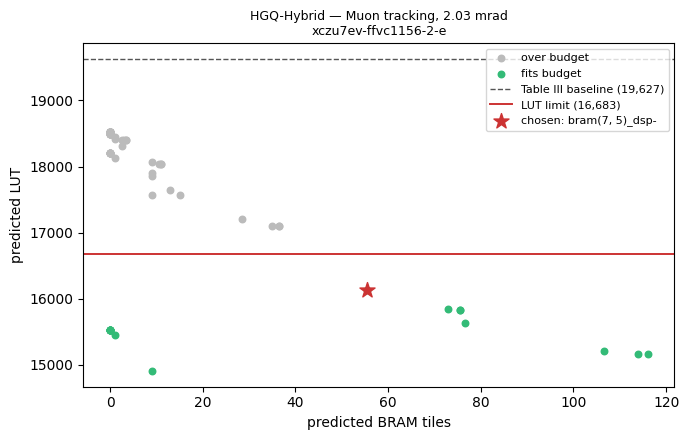

In [5]:
import matplotlib.pyplot as plt

usable = fc.budget_for(cfg).usable()        # the binding limits (after any margins)
fig, ax = plt.subplots(figsize=(7, 4.5))
ok = df[df['fits']]
no = df[~df['fits']]
ax.scatter(no['bram'], no['lut'], s=22, c='#bbb', label='over budget')
ax.scatter(ok['bram'], ok['lut'], s=22, c='#3b7', label='fits budget')
ax.axhline(cfg.baseline_lut, ls='--', c='#555', lw=1, label=f'Table III baseline ({cfg.baseline_lut:,})')
ax.axhline(usable.lut, ls='-', c='#c33', lw=1.4, label=f'LUT limit ({usable.lut:,.0f})')
if cfg.part_constrained:
    ax.axvline(usable.bram, ls=':', c='#c33', lw=1.2, label=f'BRAM limit ({usable.bram:.0f})')
if result.feasible:
    p = result.predicted
    ax.scatter([p.bram], [p.lut], s=130, marker='*', c='#c33', zorder=5, label=f'chosen: {result.config.name}')
ax.set_xlabel('predicted BRAM tiles'); ax.set_ylabel('predicted LUT')
ax.set_title(f'{cfg.title}\n{cfg.part_name}', fontsize=9)
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(NB_DIR / 'fit_front.png', dpi=130)
plt.show()


## 5) `SUMMARY.md`

In [6]:
print((NB_DIR / 'SUMMARY.md').read_text())


# Fit summary — HGQ-Hybrid — Muon tracking, 2.03 mrad

- **Part:** `xczu7ev-ffvc1156-2-e`  (230,400 LUT / 460,800 FF / 312 BRAM / 1728 DSP)
- **Published baseline (Table III):** 19,627 LUT, DSP 0
- **LUT budget (0.85×):** 16,683 LUT  (target −15%); FF/BRAM/DSP unconstrained.
- **Clock / latency cutoff:** 6.25 ns / 8 ns

- **A0 baseline (synth-calibrated LUT-only prediction):** 18,523 LUT (94% of Table III)

**FIT:** `bram(7, 5)_dsp-`
- predicted (route): **LUT 16,137** (82% of baseline → −18%), FF 6,013, BRAM 56, DSP 0, latency 12 cyc
- confirmed (route): LUT 16,607, FF 7,568, BRAM 65, DSP 0, Fmax 174.5 MHz

